# Overview
In this notebook, we investigate the role that time plays in relation to crime patterns in the city of Davis, California. Our goal is to explore how crime incidents vary across different temporal dimensions, including hour of day, day of the week, month, and season.

To accomplish this, we perform several steps including data cleaning, feature engineering, exploratory data analysis (EDA), and data visualization. We also apply statistical hypothesis testing to evaluate whether observed patterns in crime activity across time periods are statistically significant.

Together, these methods allow us to better understand how crime in Davis changes over time and whether factors such as season, time of day, or day of the week influence crime frequency. 

# Data Cleaning and Preparation

In [39]:
#Packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

crime_data = pd.read_csv(r"C:\Users\pokem\OneDrive\Documents\School\STA 141B\Data\cleaned_crime_data_2.csv")
#Exploring the data
#Seeing every city in the DF
crime_data['city'].unique()
#look at all columns
crime_data.info()
#Null values present in Place and Disposition
crime_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6553 entries, 0 to 6552
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   case_number           6553 non-null   object 
 1   report_date           6553 non-null   object 
 2   offense_description   6553 non-null   object 
 3   incident_number       6553 non-null   int64  
 4   place                 4099 non-null   object 
 5   city                  6552 non-null   object 
 6   occurrence_date       6553 non-null   object 
 7   occurrence_time       6553 non-null   object 
 8   disposition           2097 non-null   object 
 9   beat                  6484 non-null   object 
 10  x_coord               6553 non-null   float64
 11  y_coord               6553 non-null   float64
 12  block_number          6553 non-null   int64  
 13  street                6552 non-null   object 
 14  coord_check           6553 non-null   object 
 15  upload_date          

case_number                0
report_date                0
offense_description        0
incident_number            0
place                   2454
city                       1
occurrence_date            0
occurrence_time            0
disposition             4456
beat                      69
x_coord                    0
y_coord                    0
block_number               0
street                     1
coord_check                0
upload_date                0
crime_type                 0
crime_classification       0
dtype: int64

In [5]:
#Place has missing data but we are going to be using x-coord and y-coord anyway
#We will create a new df where it only includes Davis
crime_data["city"].unique()
Davis_Crime = crime_data[crime_data["city"] == "Davis"]
Davis_Crime.head()
Davis_Crime["city"].unique()
#We will drop disposition and any other col not important to our 3 main questions
# For place instead of Place we will put unknown just so its not NA
#making a copy of DF
mandatory_cols = [
    "occurrence_date",
    "occurrence_time",
    "x_coord",
    "y_coord",
    "crime_type",
    "crime_classification",
    "place"
]

Davis_Crime = Davis_Crime[mandatory_cols].copy()
Davis_Crime["place"] = Davis_Crime["place"].fillna("Unknown")
Davis_Crime.isna().sum()
#No more NA values

occurrence_date         0
occurrence_time         0
x_coord                 0
y_coord                 0
crime_type              0
crime_classification    0
place                   0
dtype: int64

In [14]:
#Checking invalid times
# Extract the hour and minute as integers to check them
hours = Davis_Crime['occurrence_time'].str.split(':').str[0].astype(float)
minutes = Davis_Crime['occurrence_time'].str.split(':').str[1].astype(float)

# Find rows where hour > 23 or minute > 59
invalid_times = Davis_Crime[(hours > 23) | (minutes > 59)]
print(invalid_times)

    occurrence_date occurrence_time     x_coord    y_coord  \
757      2023-07-13           18:64 -121.740524  38.546238   

                      crime_type crime_classification            place  
757  Driving Under the Influence          Misdemeanor  F ST DISPENSARY  


In [16]:
#Only 1 row where time is invalid 18:64 time will be changed manually to 19:04
# Update the specific row's time
Davis_Crime.at[757, 'occurrence_time'] = '19:04'

In [18]:
#Adding our new cols
# Extract hour, day of week, month, and season
Davis_Crime['hour'] = pd.to_datetime(Davis_Crime['occurrence_time']).dt.hour
Davis_Crime['day_of_week'] = pd.to_datetime(Davis_Crime['occurrence_date']).dt.dayofweek
Davis_Crime['month'] = pd.to_datetime(Davis_Crime['occurrence_date']).dt.month

# season / academic year vs summer
def season_label(date):
    month = date.month
    if 6 <= month <= 8:   # Summer
        return 'Summer'
    else:
        return 'Academic Year'

Davis_Crime['season'] = pd.to_datetime(Davis_Crime['occurrence_date']).apply(season_label)
Davis_Crime

C:\Users\pokem\AppData\Local\Temp\ipykernel_27744\4041529414.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Davis_Crime['hour'] = pd.to_datetime(Davis_Crime['occurrence_time']).dt.hour


,occurrence_date,occurrence_time,x_coord,y_coord,crime_type,crime_classification,place,hour,day_of_week,month,season
0,2021-03-18,12:07,-121.739891,38.557056,All Other Offenses,Felony,HOLMES JUNIOR HIGH SCHOOL,12,3,3,Academic Year
1,2021-11-04,22:30,-121.733101,38.560970,Larceny/Theft,Felony,NUGGET MARKET,22,3,11,Academic Year
2,2021-05-01,00:00,-121.750435,38.555664,Sex Offenses-Forcible,Felony,DAVIS HIGH SCHOOL,0,5,5,Academic Year
3,2021-11-06,00:00,-121.687393,38.553787,Burglary,Felony,PKG HOLDINGS,0,5,11,Academic Year
4,2021-11-10,16:29,-121.739601,38.546055,Assault,Misdemeanor,CORK IT AGAIN,16,2,11,Academic Year
...,...,...,...,...,...,...,...,...,...,...,...
6548,2026-02-22,13:45,-121.724716,38.540035,Larceny/Theft,Misdemeanor,SAFEWAY SOUTH,13,6,2,Academic Year
6549,2026-02-22,18:06,-121.740318,38.548645,Drug/Narcotic Offenses,Misdemeanor,DAVIS FOOD CO-OP,18,6,2,Academic Year
6550,2026-02-23,03:39,-121.747528,38.555954,Disorderly Conduct,Misdemeanor,YOLO COUNTY LIBRARY,3,0,2,Academic Year
6551,2026-02-24,09:38,-121.739965,38.543434,Drug/Narcotic Offenses,Misdemeanor,Unknown,9,1,2,Academic Year


In [20]:
#Checking our data that its fully clean
Davis_Crime.isna().sum()
#Right data types
Davis_Crime.dtypes
# Making sure all our values for Date and Time are correct
Davis_Crime['hour'].describe()
#0-23 Good
Davis_Crime['day_of_week'].describe()
#0-6 good
Davis_Crime['month'].describe()
#1-12 good
#Check duplicates
Davis_Crime[Davis_Crime.duplicated(keep=False)]
dupe_rows = Davis_Crime[Davis_Crime.duplicated(keep=False)]
dupe_rows.sort_values(list(Davis_Crime.columns))
dupes = Davis_Crime.duplicated().sum()
dupes
#9 Dupes lets drop them
Davis_Crime = Davis_Crime.drop_duplicates()
Davis_Crime.duplicated().sum()
#No more dupes
#Making sure our coords look reasonable
Davis_Crime[['x_coord','y_coord']].describe()
#Looks fine we will get a better look later
#Category Values are consistent
Davis_Crime['crime_type'].unique()

array(['All Other Offenses', 'Larceny/Theft', 'Sex Offenses-Forcible',
       'Burglary', 'Assault', 'Weapon Law Violations', 'Vandalism',
       'Fraud Offenses', 'Drug/Narcotic Offenses',
       'Driving Under the Influence', 'Motor Vehicle Theft',
       'Pornography/Obscene Material', 'Disorderly Conduct',
       'Kidnapping/Abduction', 'Curfew/Loitering/Vagrancy',
       'Stolen Property', 'Trespassing', 'Prostitution', 'Homicide',
       'Arson', 'Robbery', 'Counterfeiting/Forgery',
       'Sex Offenses-Non Forcible', 'Liquor Law Violation',
       'Embezzlement', 'Extortion/Blackmail',
       'Family Offenses Non Violent'], dtype=object)

In [22]:
#Saving our data as a csv
# Save the cleaned DataFrame to a new CSV file
Davis_Crime.to_csv('Davis_Crime_Cleaned.csv', index=False)

print("File saved successfully as 'Davis_Crime_Cleaned.csv'!")

File saved successfully as 'Davis_Crime_Cleaned.csv'!


In [ ]:
Davis_Crime

# Exploratory Data Analysis
Visualizing crime patterns by hour, day of week, month, and season.

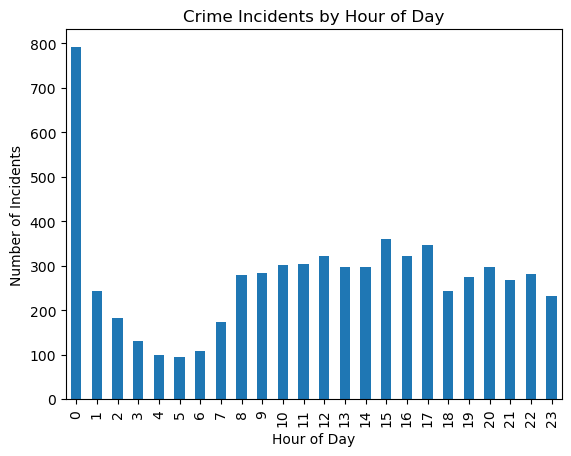

In [31]:
#Crime by Hour
crime_by_hour = Davis_Crime.groupby('hour').size()
crime_by_hour.plot(kind="bar")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.title("Crime Incidents by Hour of Day")
plt.show()
#Most Crime happens at midnight

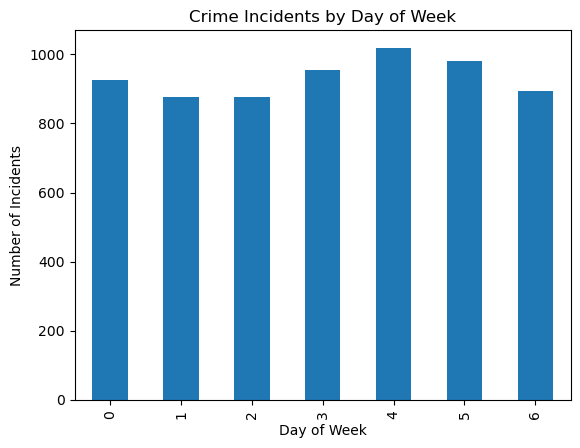

In [33]:
#Crime by day of week
crime_by_day = Davis_Crime.groupby('day_of_week').size()
crime_by_day.plot(kind = 'bar')
plt.xlabel("Day of Week")
plt.ylabel("Number of Incidents")
plt.title("Crime Incidents by Day of Week")
plt.show()
#Most Crime happens Thursday

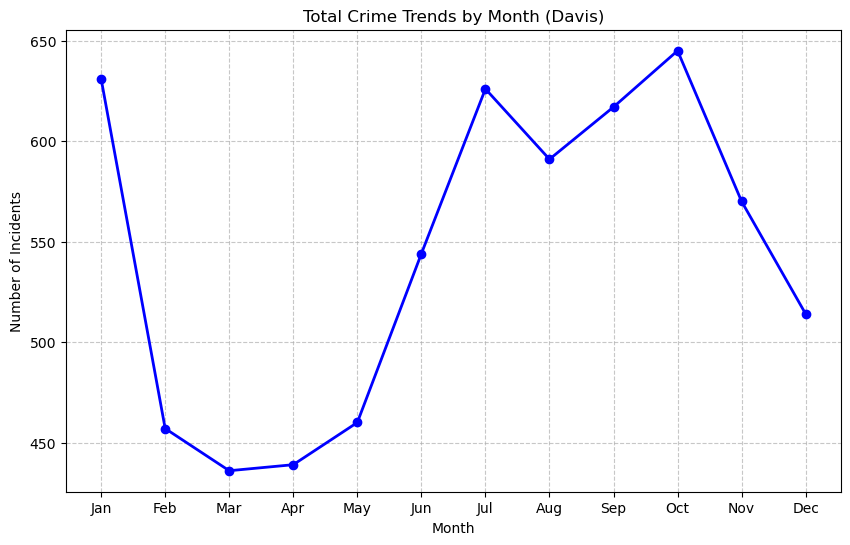

In [35]:
# 1. Group the data
crime_by_month = Davis_Crime.groupby("month").size()

# 2. Plot
plt.figure(figsize=(10, 6))
crime_by_month.plot(kind="line", marker="o", color='b', linewidth=2)

# 3. Force the X-axis to increment by 1 (Every Month)
month_numbers = range(1, 13)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.xticks(ticks=month_numbers, labels=month_names)

# 4. Labels and Title
plt.xlabel("Month")
plt.ylabel("Number of Incidents")
plt.title("Total Crime Trends by Month (Davis)")
plt.grid(True, linestyle='--', alpha=0.7) # Adding a grid makes trends easier to read
plt.show()

<Axes: xlabel='season'>

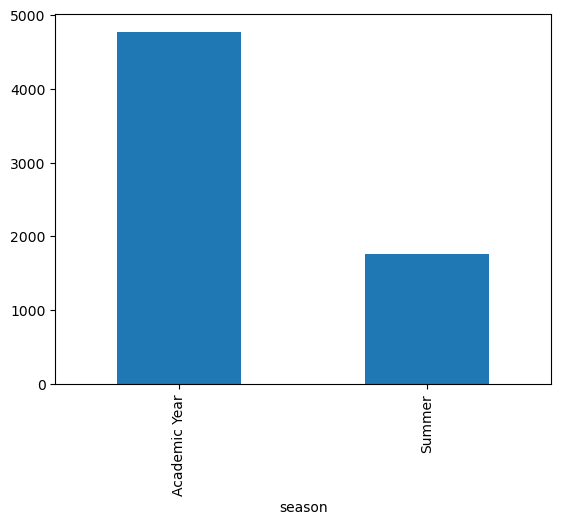

In [37]:
#season comapre
Davis_Crime.groupby("season").size().plot(kind="bar")

# Crime Characteristic Analsyis
Exploring how crime type and classification vary across different forms of times

In [45]:
# Count frequency of each crime_type
crime_counts = Davis_Crime['crime_type'].value_counts()

# Keep only the top 7 crimes
top_n = 7
top_crimes = crime_counts.index[:top_n]

# Filter the DataFrame to only top crimes
Davis_Crime_top = Davis_Crime[Davis_Crime['crime_type'].isin(top_crimes)]
# Group by hour and crime_type
hour_type = Davis_Crime_top.groupby(['hour','crime_type']).size().unstack(fill_value=0)

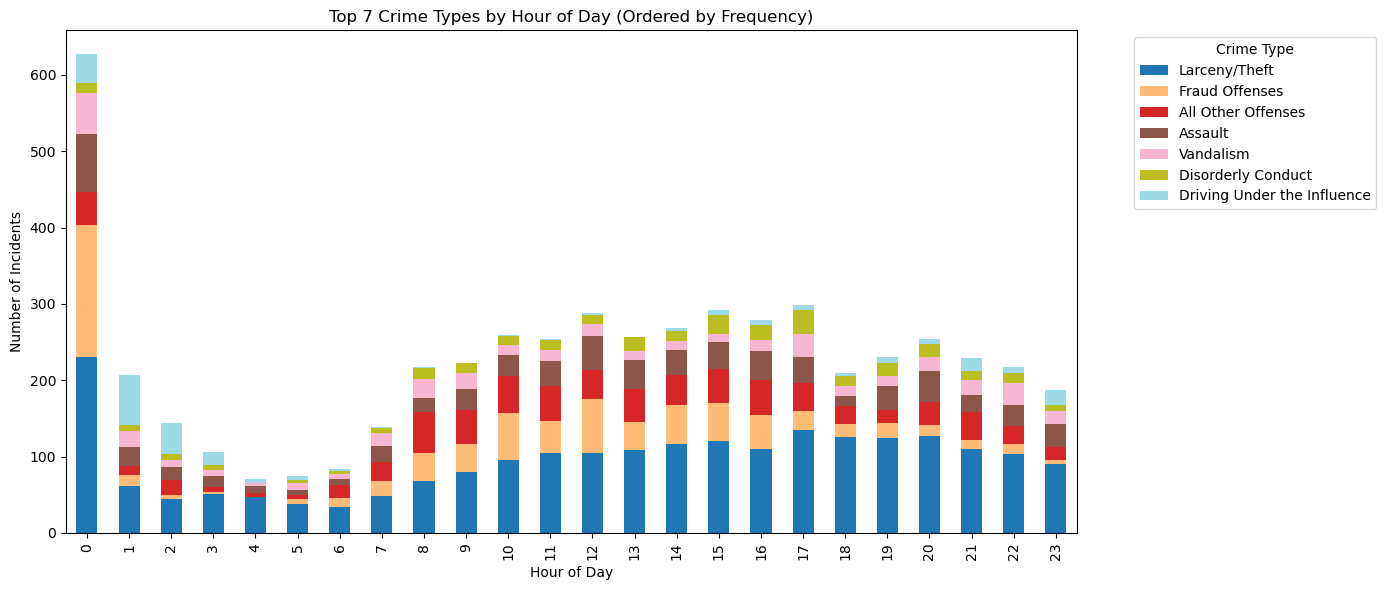

In [47]:
col_order = hour_type.sum().sort_values(ascending=False).index

# Reorder columns
hour_type_ordered = hour_type[col_order]

# Plot
hour_type_ordered.plot(kind='bar', stacked=True, figsize=(14,6), colormap='tab20')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Incidents')
plt.title('Top 7 Crime Types by Hour of Day (Ordered by Frequency)')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

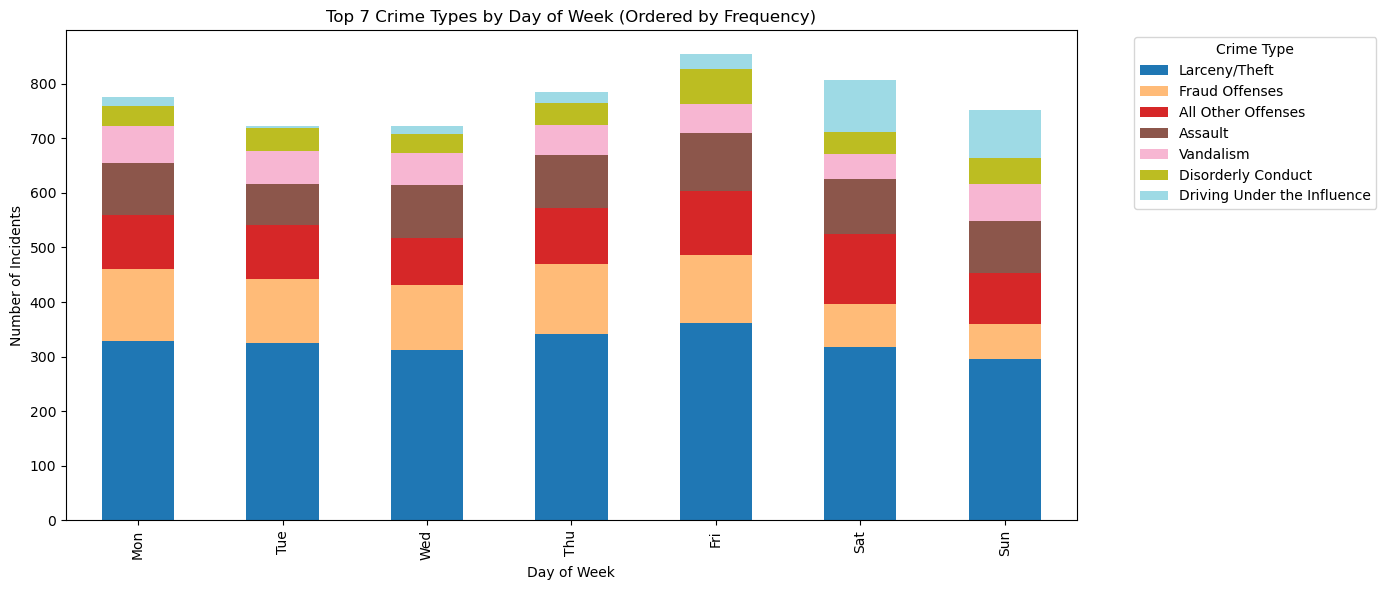

In [87]:
day_type = Davis_Crime_top.groupby(['day_of_week','crime_type']).size().unstack(fill_value=0)
day_type_ordered = day_type[col_order]
day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
day_type_ordered.index = day_type.index.map(day_names)
day_type_ordered.plot(kind='bar', stacked=True, figsize=(14,6), colormap='tab20')
plt.xlabel('Day of Week')
plt.ylabel('Number of Incidents')
plt.title('Top 7 Crime Types by Day of Week (Ordered by Frequency)')
plt.legend(title='Crime Type', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

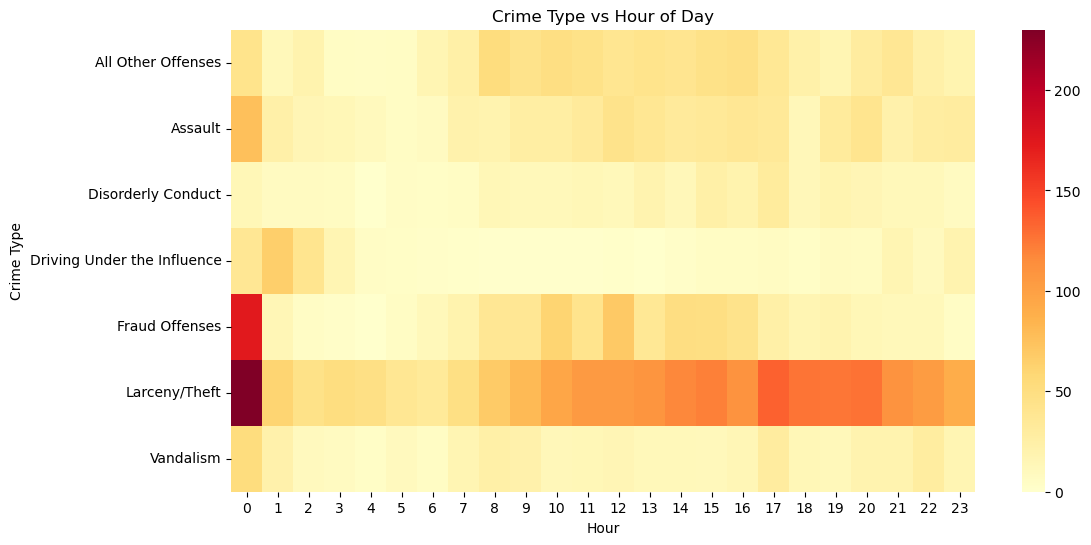

In [53]:
hour_crime = Davis_Crime_top.groupby(['crime_type','hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(hour_crime, cmap="YlOrRd")
plt.title("Crime Type vs Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Crime Type")
plt.show()

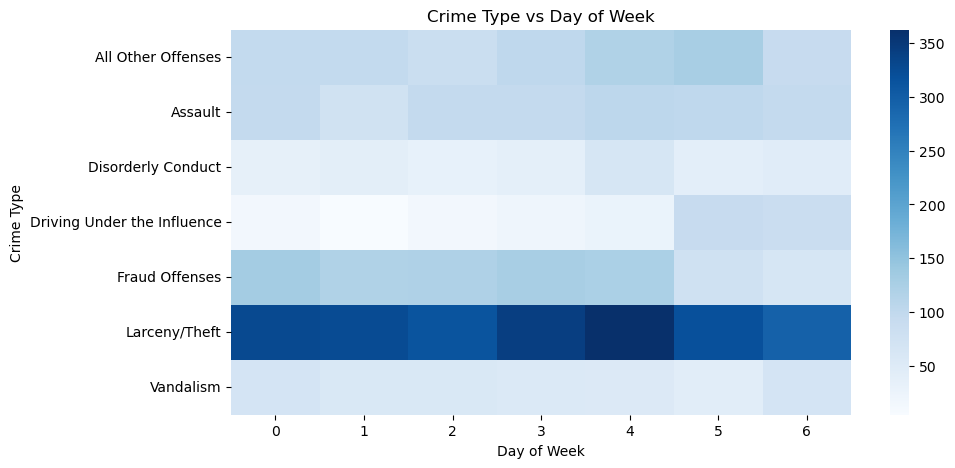

In [55]:
day_crime = Davis_Crime_top.groupby(['crime_type','day_of_week']).size().unstack(fill_value=0)

plt.figure(figsize=(10,5))
sns.heatmap(day_crime, cmap="Blues")
plt.title("Crime Type vs Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Crime Type")
plt.show()

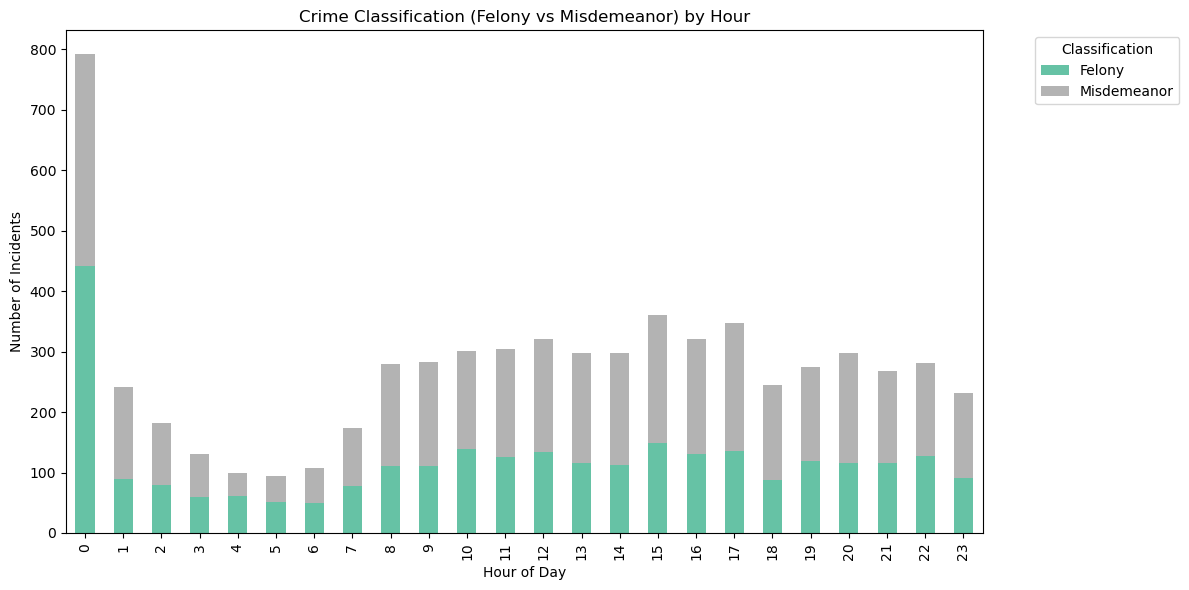

In [81]:
#Crime_Classification by hour
# Group by hour and crime_classification
hour_class = Davis_Crime.groupby(['hour','crime_classification']).size().unstack(fill_value=0)

# Plot stacked bar chart
hour_class.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Incidents')
plt.title('Crime Classification (Felony vs Misdemeanor) by Hour')
plt.legend(title='Classification', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

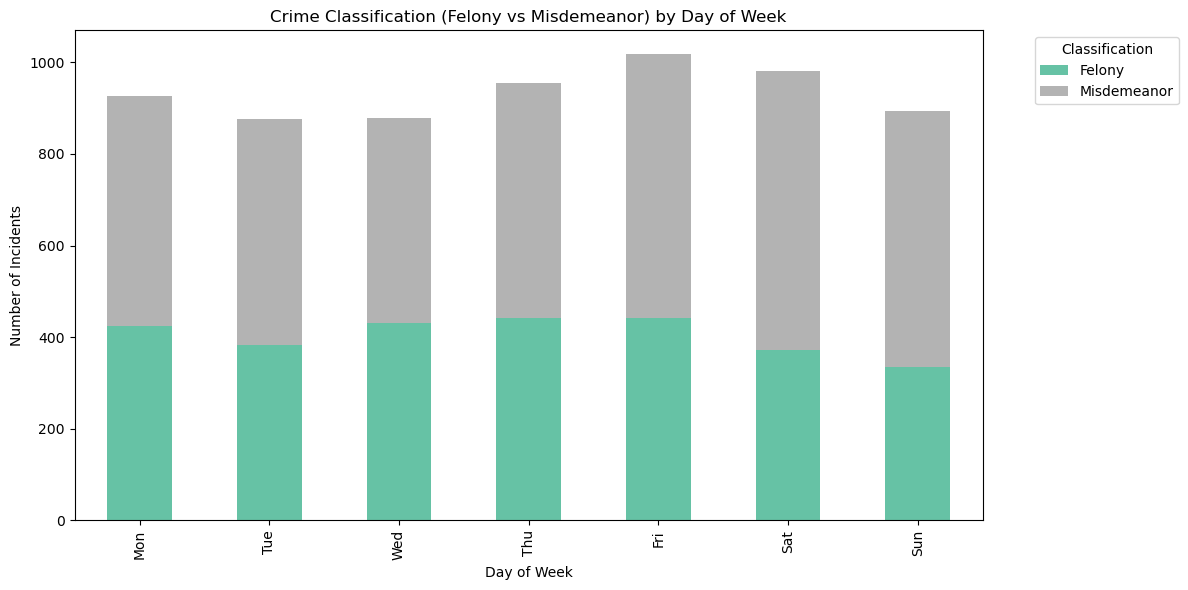

In [89]:
#Crime_classfication by day of week
# Group by day_of_week and crime_classification
day_class = Davis_Crime.groupby(['day_of_week','crime_classification']).size().unstack(fill_value=0)
day_class.index = day_class.index.map(day_names)

# Plot stacked bar chart
day_class.plot(kind='bar', stacked=True, figsize=(12,6), colormap='Set2')
plt.xlabel('Day of Week')
plt.ylabel('Number of Incidents')
plt.title('Crime Classification (Felony vs Misdemeanor) by Day of Week')
plt.legend(title='Classification', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Statistical Testing

In [77]:
#Academic yr vs school yr
# T test
from scipy.stats import ttest_ind

daily_counts = Davis_Crime.groupby(["occurrence_date","season"]).size().reset_index(name="count")

summer = daily_counts[daily_counts["season"]=="Summer"]["count"]
academic = daily_counts[daily_counts["season"]=="Academic Year"]["count"]

t_stat, p_value = ttest_ind(summer, academic, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_value)
#Very small p-value so aademic season does play a role in the amount of crime present in Davis
#More crime in Summer
print(f"Summer Mean: {summer.mean():.2f}")
print(f"Academic Year Mean: {academic.mean():.2f}")

# Calculate the difference
diff = academic.mean() - summer.mean()
print(f"Difference in daily average: {diff:.2f}")
from scipy.stats import mannwhitneyu
#doesnt care about dist so still stat significant 
u_stat, p_val_mw = mannwhitneyu(summer, academic)
print(f"u_stat:{u_stat}")
print(f"p_val_mw:{p_val_mw}")

T-statistic: 2.8646218197323114
p-value: 0.004344438576713332
Summer Mean: 5.30
Academic Year Mean: 4.61
Difference in daily average: -0.69
u_stat:187024.5
p_val_mw:0.013070410370641643


In [79]:
#Weekday vs Weekend 
Davis_Crime["weekend"] = Davis_Crime["day_of_week"].isin([5,6])

daily_counts = Davis_Crime.groupby(["occurrence_date","weekend"]).size().reset_index(name="count")

weekend = daily_counts[daily_counts["weekend"]==True]["count"]
weekday = daily_counts[daily_counts["weekend"]==False]["count"]

t_stat, p_value = ttest_ind(weekend, weekday,equal_var=False)
print("T-statistic:", t_stat)
print("p-value:", p_value)

#P value 0.37

T-statistic: 0.8715534262051768
p-value: 0.3837643764841966


C:\Users\pokem\AppData\Local\Temp\ipykernel_27744\3723752143.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Davis_Crime["weekend"] = Davis_Crime["day_of_week"].isin([5,6])


In [61]:
#Does crime differ by hour (anova)
from scipy.stats import f_oneway

hourly_counts = Davis_Crime.groupby(["occurrence_date","hour"]).size().reset_index(name="count")

groups = [group["count"] for name, group in hourly_counts.groupby("hour")]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)


F-statistic: 8.485818176688065
p-value: 1.1537398982899096e-28


In [63]:
# Does Crime differ by Month(Anova)
monthly_counts = Davis_Crime.groupby(["occurrence_date","month"]).size().reset_index(name="count")
groups = [group["count"] for name, group in monthly_counts.groupby("month")]
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 4.275199875559599
p-value: 2.7674925641185557e-06


In [65]:
# Does Crime type differ by hour
#Contigency Table
crime_hour_table = pd.crosstab(Davis_Crime["crime_type"], Davis_Crime["hour"])
#Chi Squared test
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(crime_hour_table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 2004.704021305682
p-value: 4.0555731908588996e-151


In [67]:
# Does Crime type differ by day of week
crime_day_table = pd.crosstab(Davis_Crime["crime_type"], Davis_Crime["day_of_week"])
chi2, p, dof, expected = chi2_contingency(crime_day_table)
print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 425.1893355162891
p-value: 8.403497720193445e-27


In [69]:
#Does Crime classifcation(felony/misdeamanor) differ by hour
class_hour_table = pd.crosstab(Davis_Crime["crime_classification"], Davis_Crime["hour"])

chi2, p, dof, expected = chi2_contingency(class_hour_table)
print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 98.14513488485284
p-value: 2.937807046239718e-11


In [ ]:
#Does Crime classifcation(felony/misdeamanor) differ by day of week 
class_day_table = pd.crosstab(Davis_Crime["crime_classification"], Davis_Crime["day_of_week"])

chi2, p, dof, expected = chi2_contingency(class_day_table)
print("Chi-square:", chi2)
print("p-value:", p)